In [1]:
import sys
from pathlib import Path
_root = Path.cwd().parent  # notebooks/ -> project root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root

[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
Nombre de tours : 1.0
[SegmentEngine] Démarrage : 400 segments × 50 ms  |  overlap=10 ms  |  HRIR=512 smp  |  crossfade='cosine'
[SegmentEngine] Rendu terminé : 882511 échantillons (20.01s)


### LA4 — rotation 360° sens horaire (devant → droite → derrière → gauche)

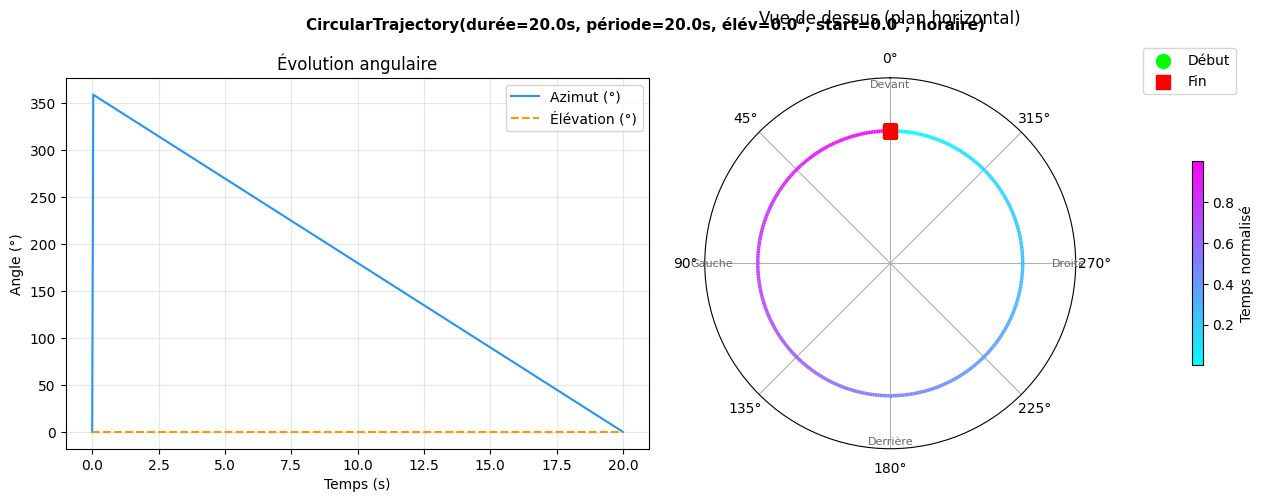

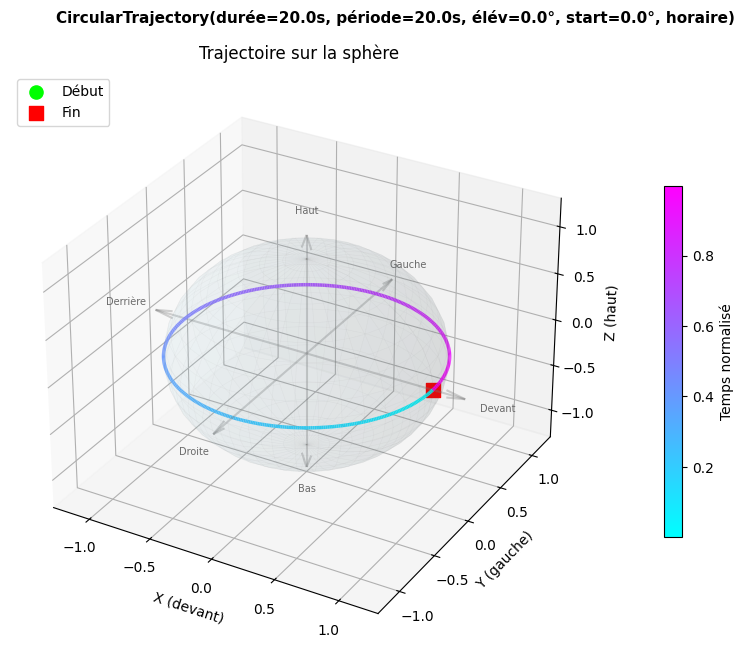

In [2]:
import numpy as np
from IPython.display import Audio, display, Markdown
from hrtf import HRTF
from GenerateSound import BurstNote, Note
from Trajectory import CircularTrajectory
from DynamicConvolver import DynamicConvolver

# ── 1. HRTF ─────────────────────────────────────────────────────────────
hrtf = HRTF.from_sofa(ROOT / "dataset" / "IRC_1002_C_44100.sofa")

# ── 2. Signal : sinus LA4 (440 Hz) ──────────────────────────────────────
duration = 20          # secondes — durée = 1 tour complet
la_burst = BurstNote(
    note           = "LA",
    octave         = 4,
    burst_duration = 0.25,   # durée de chaque rafale
    repeat_every   = 1.0,    # 1 burst par seconde → 8 impacts sur le tour
    duration       = duration,
    sr             = 44_100,
    fade_ms        = 10.0,
)
signal = la_burst.generate()


# ── 3. Trajectoire : 1 tour complet en 8 s (sens horaire) ───────────────
#   Convention SOFA, vu de dessus :
#   devant (0°) → droite (270°) → derrière (180°) → gauche (90°) → devant
traj = CircularTrajectory(
    duration_s = duration,
    period_s   = duration,   # period == duration → exactement 360°
    elevation  = 0.0,        # plan horizontal
    start_az   = 0.0,        # part de devant
    clockwise  = True,
)
print(f"Nombre de tours : {traj.n_rotations():.1f}")

# ── 4. Convolution dynamique ─────────────────────────────────────────────
conv = DynamicConvolver(
    hrtf       = hrtf,
    signal     = signal,
    sr         = la_burst.sr,
    trajectory = traj,
    segment_ms = 50,
    overlap_ms = 10,
)
output = conv.run()   # shape (N, 2)

# ── 5. Écoute ────────────────────────────────────────────────────────────
display(Markdown("### LA4 — rotation 360° sens horaire (devant → droite → derrière → gauche)"))
display(Audio(output.T, rate=la_burst.sr, normalize=False))

# ── 6. Visualisation de la trajectoire ──────────────────────────────────
traj.plot_all()

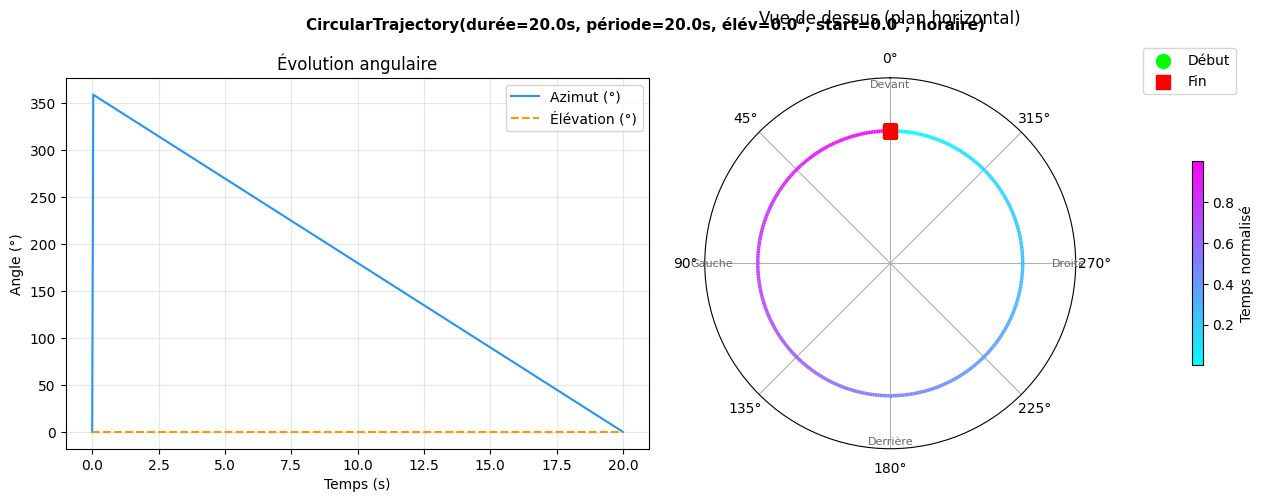

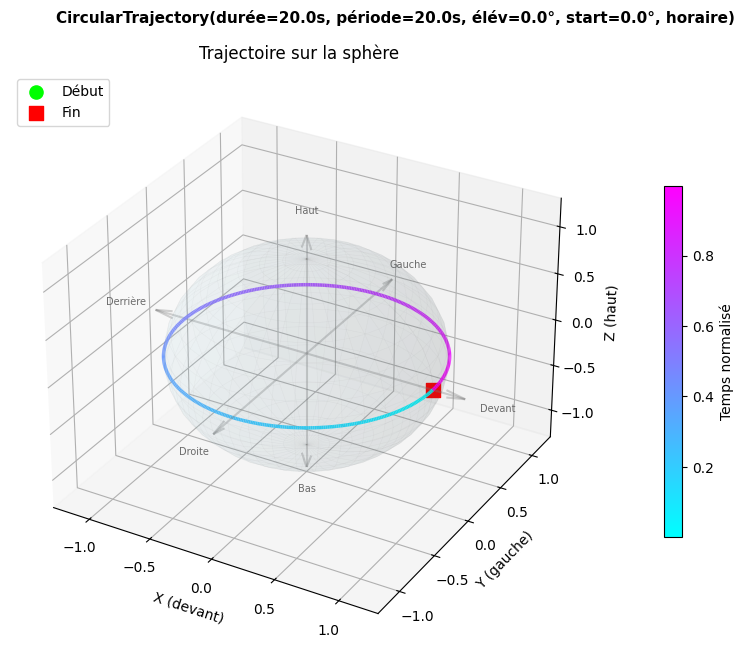

In [3]:
traj.plot_all()

In [5]:
from Trajectory import RectilinearTrajectory

# Corde de az=60° (avant-droite) → az=300° (avant-gauche)
# Les deux extrémités sont à R=2.06 m ; la corde passe devant à r_min ≈ 1.03 m
traj_rect = RectilinearTrajectory(
    duration_s = 5.0,
    start_az   = 60.0,   # avant-droit (60°)
    start_el   = 0.0,
    end_az     = 300.0,  # avant-gauche (300° ≡ −60°)
    end_el     = 0.0,
    R          = 2.06,   # rayon de la sphère HRTF (IRCAM LISTEN)
)

print(f"Angle entre extrémités  : {traj_rect.theta_deg:.1f}°")
print(f"Distance aux extrémités : {traj_rect.R:.2f} m")
print(f"Distance minimale       : {traj_rect.r_min:.2f} m  (à t = {traj_rect._duration/2:.1f} s)")
print()
print(traj_rect)


Angle entre extrémités  : 120.0°
Distance aux extrémités : 2.06 m
Distance minimale       : 1.03 m  (à t = 2.5 s)

RectilinearTrajectory(durée=5.0s, (60.0°,0.0°)→(300.0°,0.0°), R=2.06m, r_min=1.03m, θ=120.0°)


In [ ]:
import numpy as np
from IPython.display import Audio, display, Markdown

from hrtf import HRTF
from HRTFInterpolator import HRTFInterpolator
from GenerateSound import BurstNote
from Trajectory import CircularTrajectory
from DynamicConvolver import DynamicConvolver

# ── 1. Dataset + Interpolateur ────────────────────────────────────────────
#hrtf   = HRTF.from_sofa(ROOT / "dataset" / "IRC_1002_C_44100.sofa")
hrtf = HRTF.from_sofa(ROOT / "dataset" / "generic.sofa")  # générique depuis HRTFGen
interp = HRTFInterpolator(hrtf, verbose=False)

# Vérification : 22° n'est pas dans la grille de mesure
measured_elevations = sorted(set(hrtf.positions[:, 1].round(1).tolist()))
print(f"Élévations mesurées : {measured_elevations}")
print(f"22° dans la grille  : {22.0 in measured_elevations}  ← doit être False")

# ── 2. Signal : DO4 en rafales ────────────────────────────────────────────
duration = 12.0

signal_gen = Note(
    note="LA",
    octave=4,
    duration=10,
    sr=44100,
    amplitude=None,
    save=False
)
signal = signal_gen.generate()

# ── 3. Trajectoire circulaire hors grille ─────────────────────────────────
#   elevation=22° : entre les paliers mesurés 15° et 30°
#   → l'interpolateur synthétise une HRTF nouvelle à chaque segment
traj = CircularTrajectory(
    duration_s = duration,
    period_s   = duration,      
    elevation  = 1,     # hors grille : jamais mesuré directement
    start_az   = 0.0,
    clockwise  = True,
)
print(f"\n{traj}")
print(f"Nombre de tours : {traj.n_rotations():.1f}")

# ── 4. Visualiser la trajectoire ──────────────────────────────────────────
traj.plot_all()

# ── 5. Convolution dynamique avec HRTFInterpolateur ───────────────────────
"""conv = DynamicConvolver(
    hrtf           = interp,   # ← synthèse à 22° à chaque segment
    signal         = signal,
    sr             = signal_gen.sr,
    trajectory     = traj,
    segment_ms     = 100.0,
    overlap_ms     = 20.0,
    crossfade_type = "cosine",
)"""

conv = DynamicConvolver(hrtf=hrtf, signal=sig, sr=sr, trajectory=traj,
                         hop_ms=25.0)
output = conv.run()

# ── 6. Écoute + export ────────────────────────────────────────────────────
display(Markdown("### DO4 — rotation circulaire à élévation 22° (hors grille IRCAM)"))
display(Audio(output.T, rate=signal_gen.sr, normalize=False))

import soundfile as sf
out_path = ROOT / "sound" / "generated" / "cercle_hors_grille.wav"
sf.write(str(out_path), output, signal_gen.sr)
print(f"Sauvegardé : {out_path}")